In [14]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

import folium
from folium.plugins import HeatMap

In [15]:
#datasets
crime = pd.read_csv('datasets\Chicago_Crimes.csv', encoding='ISO-8859-1')
crime

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13439321,JH237424,04/14/2024 12:00:00 AM,040XX S PRAIRIE AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,...,3,38.0,06,1178707.0,1878256.0,2024,12/21/2024 03:40:46 PM,41.821236,-87.619921,"(41.821236024, -87.619920712)"
1,13437420,JH234779,04/14/2024 12:00:00 AM,023XX W CERMAK RD,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,COMMERCIAL / BUSINESS OFFICE,False,False,...,25,31.0,26,1161210.0,1889347.0,2024,12/21/2024 03:40:46 PM,41.852052,-87.683801,"(41.852051675, -87.683800849)"
2,13428676,JH224478,04/14/2024 12:00:00 AM,043XX W LE MOYNE ST,0917,MOTOR VEHICLE THEFT,"CYCLE, SCOOTER, BIKE WITH VIN",STREET,False,False,...,36,23.0,07,1146960.0,1909501.0,2024,12/21/2024 03:40:46 PM,41.907640,-87.735587,"(41.907640473, -87.735587478)"
3,13429357,JH225293,04/14/2024 12:00:00 AM,039XX W ADAMS ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,...,28,26.0,15,1150158.0,1898721.0,2024,12/21/2024 03:40:46 PM,41.877997,-87.724121,"(41.877997275, -87.724120826)"
4,13430098,JH226395,04/14/2024 12:00:00 AM,011XX W 112TH PL,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,21,75.0,06,1170856.0,1830157.0,2024,12/21/2024 03:40:46 PM,41.689421,-87.650123,"(41.6894214, -87.650123247)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249118,13805239,JJ217509,04/12/2025 12:00:00 AM,029XX W LOGAN BLVD,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,False,...,1,22.0,26,1156478.0,1917149.0,2025,04/19/2025 03:41:24 PM,41.928440,-87.700416,"(41.928439867, -87.700415972)"
249119,13804023,JJ215813,04/12/2025 12:00:00 AM,094XX S HARVARD AVE,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,False,False,...,9,49.0,04B,1175694.0,1842631.0,2025,04/19/2025 03:41:24 PM,41.723545,-87.632040,"(41.723545182, -87.632039508)"
249120,13803926,JJ215943,04/12/2025 12:00:00 AM,084XX S VINCENNES AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,21,71.0,08B,1173850.0,1848976.0,2025,04/19/2025 03:41:24 PM,41.740998,-87.638606,"(41.74099774, -87.638606337)"
249121,13803475,JJ215338,04/12/2025 12:00:00 AM,050XX S ABERDEEN ST,0530,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,True,False,...,20,61.0,04A,1169838.0,1871348.0,2025,04/19/2025 03:41:24 PM,41.802477,-87.652657,"(41.802477219, -87.652657244)"


In [16]:
crime.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

In [17]:
crime['Year'].value_counts()

Year
2024    188918
2025     60205
Name: count, dtype: int64

In [18]:
crime['Primary Type'].value_counts()

Primary Type
THEFT                                59201
BATTERY                              44579
CRIMINAL DAMAGE                      27094
ASSAULT                              22615
MOTOR VEHICLE THEFT                  19604
OTHER OFFENSE                        16781
DECEPTIVE PRACTICE                   14991
BURGLARY                              8443
ROBBERY                               8200
WEAPONS VIOLATION                     7164
NARCOTICS                             6627
CRIMINAL TRESPASS                     5045
OFFENSE INVOLVING CHILDREN            1597
CRIMINAL SEXUAL ASSAULT               1573
SEX OFFENSE                           1210
PUBLIC PEACE VIOLATION                1006
INTERFERENCE WITH PUBLIC OFFICER       771
HOMICIDE                               553
STALKING                               520
ARSON                                  452
PROSTITUTION                           287
CONCEALED CARRY LICENSE VIOLATION      249
LIQUOR LAW VIOLATION                   19

In [39]:
crime['Location Description'].value_counts()

Location Description
STREET                66040
APARTMENT             47787
RESIDENCE             29776
SIDEWALK              13265
SMALL RETAIL STORE     9858
                      ...  
SAVINGS AND LOAN          1
RETAIL STORE              1
HOTEL                     1
CHA STAIRWELL             1
CTA "L" PLATFORM          1
Name: count, Length: 128, dtype: int64

<h1>ANALYSIS OF THEFT IN CHICAGO YEAR 2024</h1>

In [72]:
#filtering data
theft1 = crime[crime['Primary Type'] == 'THEFT']
theft2 = theft1[theft1['Arrest']]
theft3 = theft1[theft1['Year'] == 2024]

#group
theft = theft3.groupby(['Latitude', 'Longitude']).size().reset_index(name = 'arrest')

#heat or point
heat_df = theft[['Latitude', 'Longitude', 'arrest']].values.tolist()

#creating man with folium then adding the heat_df in map (Adding some kwargs for non movable map)
my_map = folium.Map(location = [41.8781, -87.6298],
                    zoom_start=10,
                    dragging=False,
                    zoom_control=False,
                    scrollWheelZoom=False,
                    doubleClickZoom=False,
                    touchZoom=False)
HeatMap(heat_df).add_to(my_map)
my_map

In [73]:
theft3['Arrest'].count()

np.int64(45239)

In [74]:
percentage = (len(theft2) / len(theft1)) * 100
print(f"Percentage of thefts resulting in arrest: {percentage:.2f}%")

Percentage of thefts resulting in arrest: 7.65%


<h2>As you can see, the percentage of arrested theft is 7.65</h2>

there's a lot of possibility why the percentage of it is very low. Maybe the suspect is not recognized, the gap of reporting is a little late, lack of lead and many more

<h1>IMPACT OF LOCATION TO THEFT INCIDENT</h1>

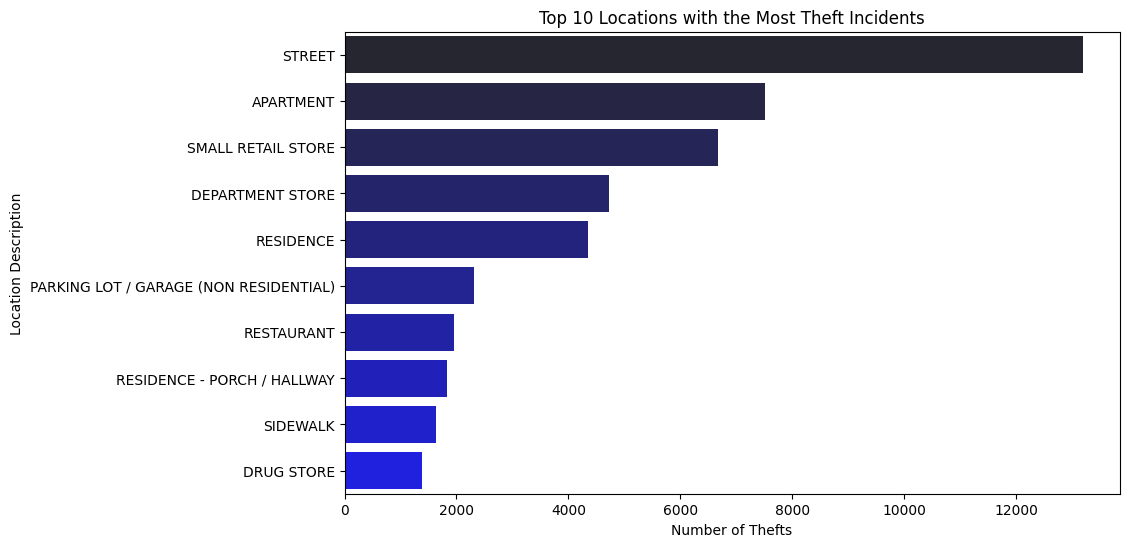

In [65]:
# Filtering data
theft1 = crime[crime['Primary Type'] == 'THEFT']
theft2 = theft1[theft1['Arrest'] == True]

# Groupby
theft3 = theft1.groupby('Location Description').size().reset_index(name='theft_count')
# Sorting data
theft3_sorted = theft3.sort_values(by='theft_count', ascending=False)

# Create a bar 
plt.figure(figsize=(10,6))
sns.barplot(x='theft_count', y='Location Description', data=theft3_sorted.head(10), palette='dark:blue')

plt.title('Top 10 Locations with the Most Theft Incidents')
plt.xlabel('Number of Thefts')
plt.ylabel('Location Description')
plt.show()

<h2>Most of the Location where theft incident happened is in street</h2>

we all know that steet is an open space, and probabbily there a a lot of people walking, wondering, and other stuff. Street is an open space, and possible that they take advantage of being in a open space to steal something

<h1>IMPACT OF LOCATION TO ARRESTED THEFT</h1>

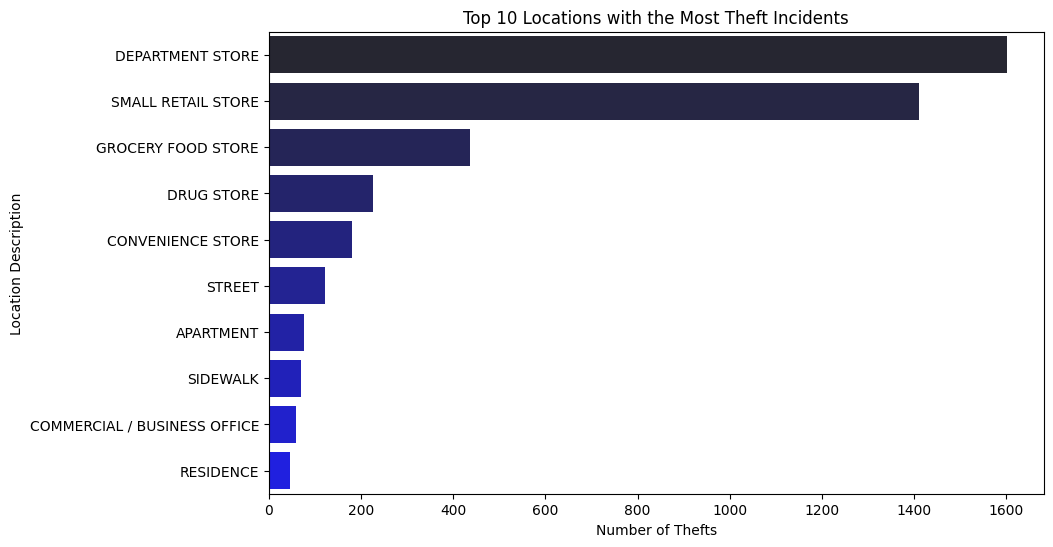

In [68]:
# Filtering data
theft1 = crime[crime['Primary Type'] == 'THEFT']
theft2 = theft1[theft1['Arrest'] == True]

# Groupby
theft3 = theft2.groupby('Location Description').size().reset_index(name='theft_count')
# Sorting data
theft3_sorted = theft3.sort_values(by='theft_count', ascending=False)

# Create a bar 
plt.figure(figsize=(10,6))
sns.barplot(x='theft_count', y='Location Description', data=theft3_sorted.head(10), palette='dark:blue')

plt.title('Top 10 Locations with the Most Theft Incidents')
plt.xlabel('Number of Thefts')
plt.ylabel('Location Description')
plt.show()

<h2>Most of the Location where theft got arrested is in stores</h2>

we all know that most of the stores has a guard, camera, and a person who watch your steps. They can provide an evidence to arrest a theft and it is possible to caught on act

<h1>INCIDENTS ON THE STREET</h1>

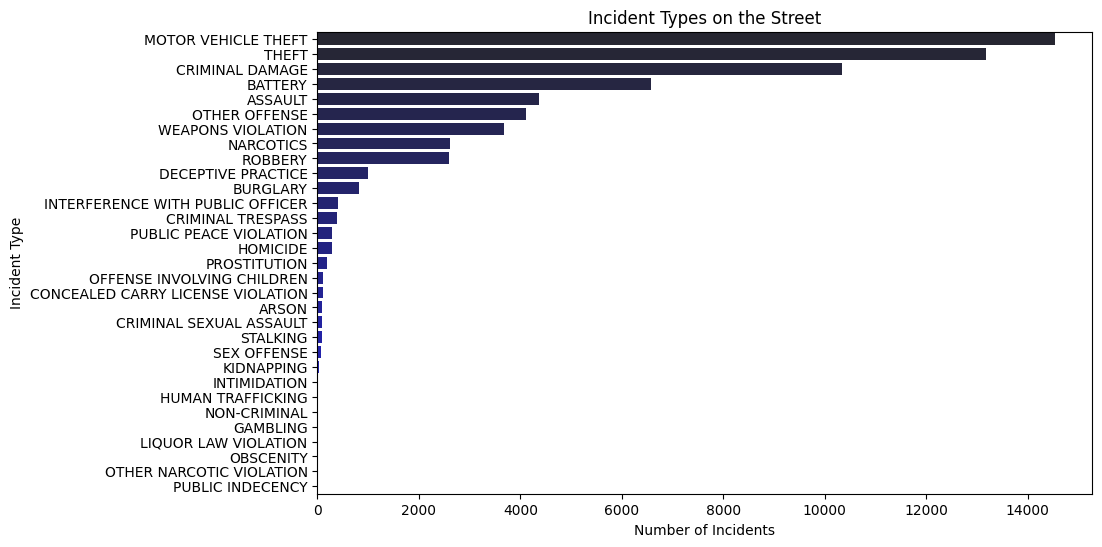

In [75]:
# Filtering data
theft1 = crime[crime['Location Description'] == 'STREET']

# Groupby
incident_types = theft1.groupby('Primary Type').size().reset_index(name='incident_count')

# Sorting
incident_types_s = incident_types.sort_values(by='incident_count', ascending=False)

#Creating graph
plt.figure(figsize=(10, 6))
sns.barplot(x='incident_count', y='Primary Type', data=incident_types_s, palette='dark:blue')

plt.title('Incident Types on the Street')
plt.xlabel('Number of Incidents')
plt.ylabel('Incident Type')
plt.show()

<h2>Most of the Incident in the street is theft</h2>

<h1>MOST INCIDENT HAPPENED ON  RESIDENCE </h1>

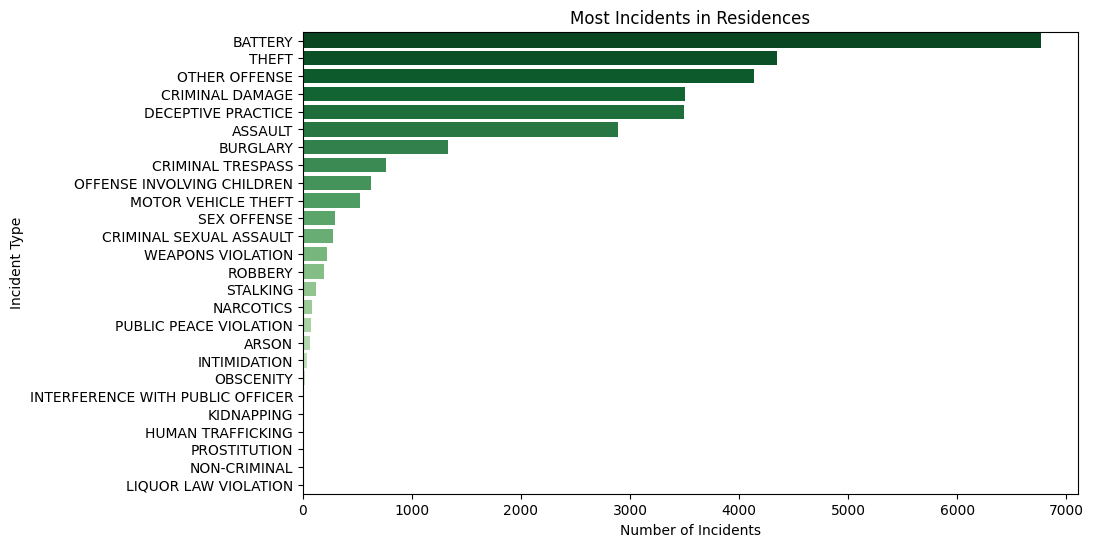

In [84]:
residence = crime[crime['Location Description'] == 'RESIDENCE']

count = residence.groupby('Primary Type').size().reset_index(name='count')

common_in = count.sort_values(by='count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='Primary Type', data=common_in, palette='Greens_r')

plt.title('Most Incidents in Residences')
plt.xlabel('Number of Incidents')
plt.ylabel('Incident Type')

plt.show()

<h2>Most of the Incident happened in residences is Battery</h2>

<h1>PERCENTAGE OF BATTERY</h1>

In [88]:
total_in = len(crime)

battery = crime[crime['Primary Type'] == 'BATTERY']
total_b = len(battery)

# Calculate percentage
battery_percentage = (total_b / total_in) * 100
print(f"Percentage of Battery incidents in overall incidents: {battery_percentage:.2f}%")


Percentage of Battery incidents in overall incidents: 17.89%
